<a href="https://colab.research.google.com/github/dani503sv/parcial4_DanielAmaya_2513232022/blob/main/parcial4_SegundaParte_ejercicio1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 Ejercicio 1: Análisis de Asociación

In [1]:
!pip install mlxtend -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from mlxtend.frequent_patterns import apriori, association_rules

url = "https://raw.githubusercontent.com/dani503sv/parcial4_DanielAmaya_2513232022/refs/heads/main/Archivos/clave_F_asociacion.csv"

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [3]:
df = pd.read_csv(url)
df.head(10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,transaccion_id,cliente_id,fecha,categoria,item,cantidad,canal
0,F-T0001,F-C0058,2026-01-02,Ropa,Camiseta,4,Tienda
1,F-T0001,F-C0058,2026-01-02,Ciclismo,Casco,1,Tienda
2,F-T0001,F-C0058,2026-01-02,Futbol,Chaleco,1,Tienda
3,F-T0001,F-C0058,2026-01-02,Ciclismo,Luces,1,Tienda
4,F-T0002,F-C0005,2026-01-09,Ciclismo,Casco,1,App
5,F-T0002,F-C0005,2026-01-09,Futbol,Guantes,2,App
6,F-T0003,F-C0035,2026-02-18,Fitness,Banda_elastica,1,Tienda
7,F-T0003,F-C0035,2026-02-18,Ciclismo,Candado,1,Tienda
8,F-T0003,F-C0035,2026-02-18,Fitness,Mat,1,Tienda
9,F-T0004,F-C0077,2026-01-28,Ropa,Calcetas,4,Web


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Se cargó correctamente el archivo CSV desde GitHub. Cada fila representa un producto comprado dentro de una transacción, por lo que una misma transacción puede aparecer en varias filas cuando el cliente compró varios artículos.

In [4]:
print("Dimensiones del dataset:", df.shape)
print("\nColumnas:")
print(df.columns.tolist())

print("\nTipos de datos:")
print(df.dtypes)

print("\nValores nulos por columna:")
print(df.isnull().sum())

print("\nRegistros duplicados exactos:")
print(df.duplicated().sum())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Dimensiones del dataset: (605, 7)

Columnas:
['transaccion_id', 'cliente_id', 'fecha', 'categoria', 'item', 'cantidad', 'canal']

Tipos de datos:
transaccion_id    object
cliente_id        object
fecha             object
categoria         object
item              object
cantidad           int64
canal             object
dtype: object

Valores nulos por columna:
transaccion_id    0
cliente_id        0
fecha             0
categoria         0
item              0
cantidad          0
canal             1
dtype: int64

Registros duplicados exactos:
1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

En esta etapa se valida la calidad inicial de los datos. Se revisan dimensiones, nombres de columnas, tipos, valores nulos y registros duplicados para detectar problemas que puedan afectar la construcción de las reglas de asociación.

In [5]:
df.sample(10, random_state=42)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,transaccion_id,cliente_id,fecha,categoria,item,cantidad,canal
412,F-T0132,F-C0052,2026-02-14,Futbol,Guantes,2,App
289,F-T0093,F-C0012,2026-03-21,Fitness,Mancuernas,3,Tienda
76,F-T0024,F-C0036,2026-01-26,Fitness,Mancuernas,1,Tienda
78,F-T0025,F-C0065,2026-01-12,Fitness,Mat,1,App
182,F-T0058,F-C0019,2026-01-11,Ciclismo,Luces,1,App
594,F-T0188,F-C0056,2026-04-19,Suplementos,Bebida_isotonica,1,Tienda
10,F-T0004,F-C0077,2026-01-28,Suplementos,Creatina,1,Web
131,F-T0042,F-C0046,2026-03-18,Ropa,Calcetas,3,Web
443,F-T0139,F-C0061,2026-04-09,Fitness,Mat,2,Tienda
86,F-T0027,F-C0002,2026-02-03,Fitness,Banda_elastica,3,Tienda


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

La estructura del archivo incluye transaccion_id como identificador de compra, cliente_id, fecha, categoria, item, cantidad y canal. Para reglas de asociación, la variable más importante será item, agrupada por transaccion_id, porque permite descubrir qué productos se compran juntos.

In [6]:
df.columns = df.columns.str.strip()

df["item"] = df["item"].astype(str).str.strip()
df["categoria"] = df["categoria"].astype(str).str.strip()
df["transaccion_id"] = df["transaccion_id"].astype(str).str.strip()

df["canal"] = df["canal"].fillna("No_especificado")

print(df.isnull().sum())

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

transaccion_id    0
cliente_id        0
fecha             0
categoria         0
item              0
cantidad          0
canal             0
dtype: int64


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Se realizó una limpieza básica del dataset para evitar errores de formato. En especial, se completaron valores faltantes en canal, aunque esa columna no será la base del modelo principal de asociación

In [7]:
basket = (
    df.groupby(["transaccion_id", "item"])["cantidad"]
    .sum()
    .unstack()
    .fillna(0)
)

basket = basket.applymap(lambda x: 1 if x > 0 else 0)

basket.head()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

item,Balon,Banda_elastica,Barra_energia,Bebida_isotonica,Calcetas,Camiseta,Candado,Casco,Chaleco,Conos,Creatina,Guantes,Guantes_bici,Luces,Mancuernas,Mat,Proteina,Short,Tenis,Termo
transaccion_id,,,,,,,,,,,,,,,,,,,,
F-T0001,0,0,0,0,0,1,0,1,1,0,0,0,0,1,0,0,0,0,0,0
F-T0002,0,0,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,0,0
F-T0003,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0
F-T0004,0,0,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,1,0
F-T0005,1,0,0,0,0,0,0,0,0,1,0,0,1,0,1,0,0,0,0,1


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Se transformó el dataset a formato transaccional tipo cesta de compra. Ahora cada fila representa una transacción y cada columna representa un producto; el valor 1 indica que el producto estuvo presente en esa compra y 0 indica ausencia

In [8]:
print("Cantidad de transacciones:", basket.shape[0])
print("Cantidad de productos únicos:", basket.shape[1])
print("\nProductos:")
print(basket.columns.tolist())

Cantidad de transacciones: 190
Cantidad de productos únicos: 20

Productos:
['Balon', 'Banda_elastica', 'Barra_energia', 'Bebida_isotonica', 'Calcetas', 'Camiseta', 'Candado', 'Casco', 'Chaleco', 'Conos', 'Creatina', 'Guantes', 'Guantes_bici', 'Luces', 'Mancuernas', 'Mat', 'Proteina', 'Short', 'Tenis', 'Termo']


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Después de la transformación, el análisis ya está listo para minería de asociaciones. La cantidad de columnas representa el número de productos distintos encontrados en todas las transacciones.

In [9]:
frequent_itemsets = apriori(basket, min_support=0.05, use_colnames=True)
frequent_itemsets = frequent_itemsets.sort_values(by="support", ascending=False)

frequent_itemsets.head(10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,support,itemsets
18,0.268421,(Tenis)
13,0.257895,(Luces)
1,0.252632,(Banda_elastica)
4,0.252632,(Calcetas)
0,0.226316,(Balon)
7,0.226316,(Casco)
15,0.215789,(Mat)
9,0.210526,(Conos)
25,0.152632,"(Tenis, Calcetas)"
3,0.152632,(Bebida_isotonica)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Aquí se identifican los conjuntos frecuentes de productos. El soporte mide qué proporción de transacciones contiene cada combinación

In [10]:
rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.4)

rules = rules.sort_values(by=["lift", "confidence", "support"], ascending=False)

rules.head(10)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
3,(Mat),(Banda_elastica),0.215789,0.252632,0.136842,0.634146,2.510163,1.0,0.082327,2.042807,0.767166,0.412698,0.510477,0.587907
2,(Banda_elastica),(Mat),0.252632,0.215789,0.136842,0.541667,2.510163,1.0,0.082327,1.711005,0.804984,0.412698,0.415548,0.587907
7,(Balon),(Conos),0.226316,0.210526,0.115789,0.511628,2.430233,1.0,0.068144,1.616541,0.760668,0.360656,0.381395,0.530814
6,(Conos),(Balon),0.210526,0.226316,0.115789,0.550000,2.430233,1.0,0.068144,1.719298,0.745455,0.360656,0.418367,0.530814
1,(Calcetas),(Tenis),0.252632,0.268421,0.152632,0.604167,2.250817,1.0,0.084820,1.848199,0.743565,0.414286,0.458933,0.586397
0,(Tenis),(Calcetas),0.268421,0.252632,0.152632,0.568627,2.250817,1.0,0.084820,1.732536,0.759613,0.414286,0.422811,0.586397
5,(Casco),(Luces),0.226316,0.257895,0.121053,0.534884,2.074039,1.0,0.062687,1.595526,0.669329,0.333333,0.373248,0.502136
4,(Luces),(Casco),0.257895,0.226316,0.121053,0.469388,2.074039,1.0,0.062687,1.458097,0.697811,0.333333,0.314175,0.502136
8,(Guantes_bici),(Calcetas),0.136842,0.252632,0.057895,0.423077,1.674679,1.0,0.023324,1.295439,0.466741,0.174603,0.228061,0.326122


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Las reglas se generan a partir de los itemsets frecuentes. La confianza indica qué tan probable es encontrar el consecuente cuando aparece el antecedente, mientras que el lift muestra si la relación es más fuerte que una coincidencia aleatoria.

In [11]:
top_rules = rules.copy()

top_rules["antecedente"] = top_rules["antecedents"].apply(lambda x: ", ".join(list(x)))
top_rules["consecuente"] = top_rules["consequents"].apply(lambda x: ", ".join(list(x)))

top_10 = top_rules[[
    "antecedente", "consecuente", "support", "confidence", "lift"
]].head(10)

top_10

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedente,consecuente,support,confidence,lift
3,Mat,Banda_elastica,0.136842,0.634146,2.510163
2,Banda_elastica,Mat,0.136842,0.541667,2.510163
7,Balon,Conos,0.115789,0.511628,2.430233
6,Conos,Balon,0.115789,0.550000,2.430233
1,Calcetas,Tenis,0.152632,0.604167,2.250817
0,Tenis,Calcetas,0.152632,0.568627,2.250817
5,Casco,Luces,0.121053,0.534884,2.074039
4,Luces,Casco,0.121053,0.469388,2.074039
8,Guantes_bici,Calcetas,0.057895,0.423077,1.674679


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [12]:
top_10_style = top_10.copy()
top_10_style["support"] = top_10_style["support"].round(3)
top_10_style["confidence"] = top_10_style["confidence"].round(3)
top_10_style["lift"] = top_10_style["lift"].round(3)

top_10_style

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,antecedente,consecuente,support,confidence,lift
3,Mat,Banda_elastica,0.137,0.634,2.510
2,Banda_elastica,Mat,0.137,0.542,2.510
7,Balon,Conos,0.116,0.512,2.430
6,Conos,Balon,0.116,0.550,2.430
1,Calcetas,Tenis,0.153,0.604,2.251
0,Tenis,Calcetas,0.153,0.569,2.251
5,Casco,Luces,0.121,0.535,2.074
4,Luces,Casco,0.121,0.469,2.074
8,Guantes_bici,Calcetas,0.058,0.423,1.675


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

En esta tabla se presentan las 10 reglas más relevante lift, confianza y soporte. Estas reglas permiten identificar combinaciones de productos que aparecen juntas con mayor frecuencia y utilidad comercial.

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

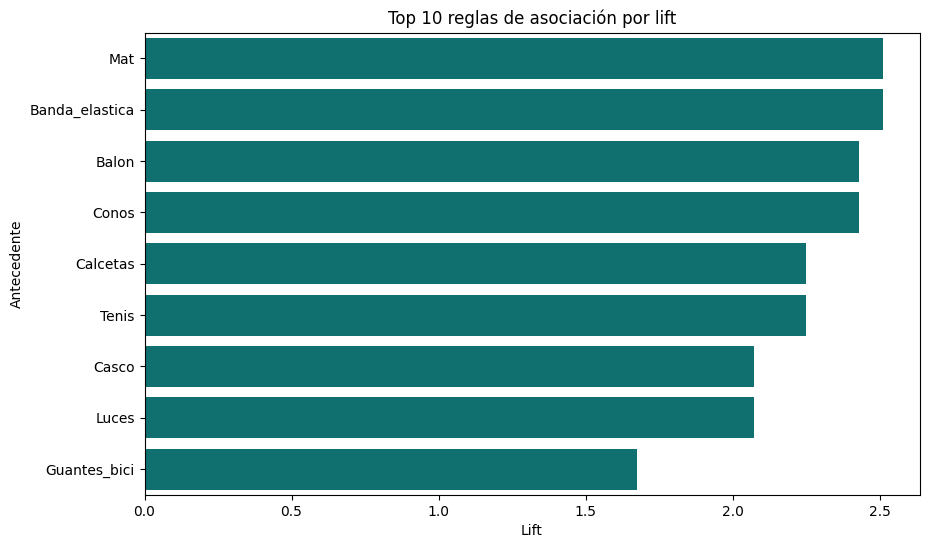

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

In [13]:
plt.figure(figsize=(10,6))
sns.barplot(data=top_10_style, x="lift", y="antecedente", color="teal")
plt.title("Top 10 reglas de asociación por lift")
plt.xlabel("Lift")
plt.ylabel("Antecedente")
plt.show()

In [15]:
for i, row in top_10_style.head(5).iterrows():
    print(f"Regla: Si un cliente compra [{row['antecedente']}], también tiende a comprar [{row['consecuente']}].")
    print(f"Soporte: {row['support']} | Confianza: {row['confidence']} | Lift: {row['lift']}")
    print("-" * 100)

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Regla: Si un cliente compra [Mat], también tiende a comprar [Banda_elastica].
Soporte: 0.137 | Confianza: 0.634 | Lift: 2.51
----------------------------------------------------------------------------------------------------
Regla: Si un cliente compra [Banda_elastica], también tiende a comprar [Mat].
Soporte: 0.137 | Confianza: 0.542 | Lift: 2.51
----------------------------------------------------------------------------------------------------
Regla: Si un cliente compra [Balon], también tiende a comprar [Conos].
Soporte: 0.116 | Confianza: 0.512 | Lift: 2.43
----------------------------------------------------------------------------------------------------
Regla: Si un cliente compra [Conos], también tiende a comprar [Balon].
Soporte: 0.116 | Confianza: 0.55 | Lift: 2.43
----------------------------------------------------------------------------------------------------
Regla: Si un cliente compra [Calcetas], también tiende a comprar [Tenis].
Soporte: 0.153 | Confianza: 0.604 | L

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

Las reglas con mayor lift representan asociaciones especialmente útiles para estrategias de venta cruzada. Si una combinación presenta buena confianza y lift mayor que 1, significa que el consecuente aparece con más frecuencia de la esperada cuando ya existe el antecedente.

Interpretación de negocio

1. Las reglas encontradas permiten identificar productos que suelen comprarse juntos dentro de una misma transacción.
2. Las combinaciones con mayor confianza pueden utilizarse para sugerencias automáticas durante el proceso de compra.
3. Las reglas con mayor lift son especialmente valiosas porque indican asociaciones más fuertes que una coincidencia aleatoria.

Recomendaciones comerciales

1. Crear promociones o combos con los productos que aparezcan juntos con mayor frecuencia.
2. Implementar venta cruzada en la web, app o tienda mostrando productos relacionados al seleccionar un artículo.
3. Diseñar campañas por categoría o producto usando las asociaciones detectadas para aumentar el ticket promedio.

Conclusión

El análisis de asociación permite descubrir patrones de compra útiles para decisiones comerciales. Con esta información, la empresa puede mejorar promociones, recomendaciones de productos y estrategias de cross-selling basadas en evidencia del comportamiento real de compra.